In [1]:
import numpy             as np
import matplotlib.pyplot as plt
import seaborn           as sns
import pandas            as pd
import os
import sys

# Assuming the `bin` directory is in the user's home directory
# For sqs
home_directory = os.path.expanduser("~")
bin_directory = os.path.join(home_directory, "bin")
os.environ["PATH"] += os.pathsep + bin_directory

from ase.build                                         import sort
from pymatgen.core.surface                             import generate_all_slabs
from pymatgen.io.vasp.inputs                           import Poscar
from pymatgen.core.structure                           import Structure
from pymatgen.core.lattice                             import Lattice
from pymatgen.transformations.advanced_transformations import SQSTransformation
from pymatgen.core.structure                           import Structure, Lattice

sys.path.append('../../UCL/m3gnet')
import ML_library as MLL

sns.set_theme()

We only consider coherent interfaces (which has matching lattices from both sides of the interface, meaning that there is a repeat along the interface that lets build periodicity along the interface surface).

In [ ]:
for n, slab in enumerate(slabs):
    print(n, "Polar:" ,slab.is_polar(), "Symmetric: ", slab.is_symmetric())

In [2]:
# Define name of folder and path to reference POSCAR
general_folder = 'input/BiSI'
path_to_POSCAR = 'POSCAR-uc-CeO2'

# Maximum number for the Miller index in each direction
max_index = 3

# Whether to repair terminations with broken bonds or just omit them
repair = True

# Minimum thicknesses for slab and vacuum
min_slab_size   = 20.0
min_vacuum_size = 20.0

# Define paths to pretrained model and structure to be relaxed
# Materials Project pretrained model as default
#model_load_path = '../../UCL/m3gnet/finetuned_model'
model_load_path = None
model_load_path = '../../UCL/m3gnet/M3GNet-MP-2021.2.8-PES' if model_load_path is None else model_load_path
model_load_path

'../../UCL/m3gnet/M3GNet-MP-2021.2.8-PES'

In [3]:
# Move POSCAR to defect folder
# The folder is named as defects_x_y_z_vi (eg, defects_0_1_0.5_v0)
# Each new run generates a new folder, with different defects most likely (as POSCAR will vary as well)
i = 0
while True:
    if not os.path.exists(general_folder):
        # Generate new folder
        os.system(f'mkdir {general_folder}')
    
    slab_folder = f'{general_folder}/slab_v{i}'
    if not os.path.exists(slab_folder):
        # Generate new folder
        os.system(f'mkdir {slab_folder}')

        # Copy POSCAR there (named as unticell, and POSCAR for creating supercell)
        os.system(f'cp {path_to_POSCAR} {slab_folder}/POSCAR')
        break
    i +=1
slab_folder

'input/BiSI/slab_v1'

# ML-IAP relaxation

In [4]:
# Unit-cell relaxation

# Define paths to bulk and POSCAR
path_to_bulk = f'{slab_folder}/bulk'

# Generate directory for current slab
os.system(f'mkdir {path_to_bulk}')

# Copy POSCAR to new directory
os.system(f'cp {slab_folder}/POSCAR {path_to_bulk}/POSCAR')

# Relax the structure, hiding the output (verbose=False)
_ = MLL.structural_relaxation(path_to_bulk,
                              model_load_path,
                              verbose=False)

# Get the single-shot energy
bulk_energy = MLL.single_shot_energy_calculations(f'{path_to_bulk}/CONTCAR',
                                                  model_load_path)

# Slab generation

In [6]:
# Read relaxed structure
structure = Structure.from_file(f'{path_to_bulk}/CONTCAR')

# Generate all slabs
slabs = generate_all_slabs(structure,
                           max_index=max_index,
                           min_slab_size=min_slab_size,
                           min_vacuum_size=min_vacuum_size,
                           repair=repair)

# Get energy per atom
bulk_energy_per_atom = bulk_energy / structure.num_sites

Surface formation energy of shape $S$ for slab of energy $E_S$ with $N$ formula units and $E_{bulk}$ bulk energy is:

\begin{equation}
    E_S = \frac{E_S - E_{bulk}}{2 S}
\end{equation}

where all energies are per atom.

In [7]:
# Initialize the data dictionary for storing all slab energy calculations
slab_energies = {}

# Iterate over slabs
for i, slab in enumerate(slabs):
    print()
    print(f'Slab {i+1}')
    print()
    print('Miller index:', slab.miller_index)
    print('Shift:', slab.shift)
    print('Surface area:', slab.surface_area)
    print('Number of sites:', len(slab.sites))

    # Miller index tuple to string
    miller_index_str = '_'.join(str(element) for element in slab.miller_index)
    miller_index_str = f'{miller_index_str}_i_{i}'
    
    # Define current folder
    current_folder = f'{slab_folder}/{miller_index_str}'
    
    # Generate new folder
    os.system(f'mkdir {current_folder}')
    
    # Save slab into current_folder
    slab.to(f'{current_folder}/POSCAR')
    
    # Relax the structure, hiding the output (verbose=False)
    _ = MLL.structural_relaxation(current_folder,
                                  model_load_path,
                                  verbose=False,
                                  relax_cell=False)
    
    # Get the single-shot energy
    ssc_energy = MLL.single_shot_energy_calculations(f'{current_folder}/POSCAR',
                                                     model_load_path)
    
    # Get energy per atom
    ssc_energy_per_atom = ssc_energy / len(slab.sites)
    
    # Compute slab energy in eV/atom/ang^2
    slab_energy = (ssc_energy_per_atom - bulk_energy_per_atom) / (2 * slab.surface_area)
    
    print(f'\t{slab_energy} eV/atom/Å^2')

    # Generate a dictionary object with the new data
    new_data = {(miller_index_str): slab_energy}

    # Update in the main data object
    slab_energies.update(new_data)

# Convert to Pandas DataFrame
slab_energies = pd.DataFrame(slab_energies, index=['energy'])


Slab 1

Miller index: (1, 1, 1)
Shift: 0.12499999731053357
Surface area: 12.913723710327742
Number of sites: 21
	0.013503044071157015 eV/atom/Å^2

Slab 2

Miller index: (1, 1, 1)
Shift: 0.4999999958184571
Surface area: 12.913723710327742
Number of sites: 21
	0.0019644330406173066 eV/atom/Å^2

Slab 3

Miller index: (1, 1, 0)
Shift: 0.2500000030142272
Surface area: 21.087740692513755
Number of sites: 36
	0.0019649825786576115 eV/atom/Å^2

Slab 4

Miller index: (1, 0, 0)
Shift: 0.1250000013556791
Surface area: 14.910686696964738
Number of sites: 24
	0.00985076960462207 eV/atom/Å^2

Slab 5

Miller index: (2, 2, 1)
Shift: 0.06249999837307785
Surface area: 44.73405267241261
Number of sites: 72
	0.0017416120155982623 eV/atom/Å^2

Slab 6

Miller index: (2, 1, 1)
Shift: 0.1249999965752644
Surface area: 36.524550297197685
Number of sites: 60
	0.001887508988088261 eV/atom/Å^2

Slab 7

Miller index: (2, 1, 0)
Shift: 0.06250000043628479
Surface area: 33.341843742969004
Number of sites: 60
	0.00248

# Extract local minimas and generate input files

In [8]:
# Sorted in ascendent order
min_arg       = np.argsort(slab_energies.values)[0]
local_minimas = slab_energies.columns[min_arg]
energies      = slab_energies.values[0][min_arg]

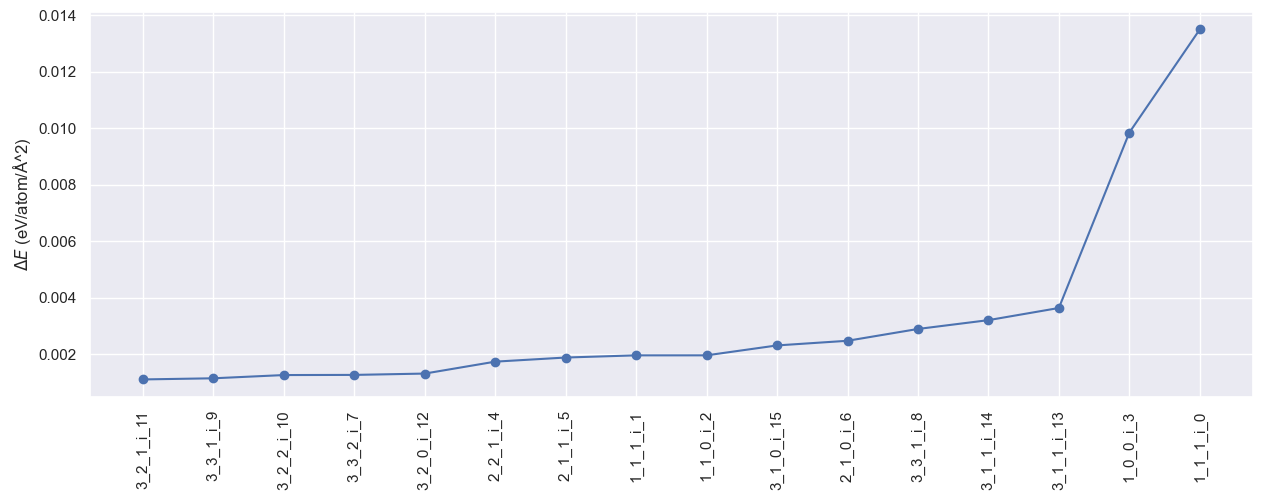

In [9]:
# Energy differences in eV/supercell
plt.figure(figsize=(15, 5))
plt.plot(energies, 'o-')
plt.xticks(range(len(local_minimas)), local_minimas, rotation='vertical')
plt.ylabel(r'$\Delta E$ (eV/atom/Å^2)')
plt.savefig(f'{slab_folder}/ranking.eps', dpi=50, bbox_inches='tight')
plt.show()